
Reading files:
outputs/n_substeps-1/outputs/tracer_analysis/elevation_tracer_rank_0.txt
outputs/n_substeps-2/outputs/tracer_analysis/elevation_tracer_rank_0.txt

Saved figure:
figures_tracer_plots/comparison_n_substeps-1_vs_n_substeps-2.png


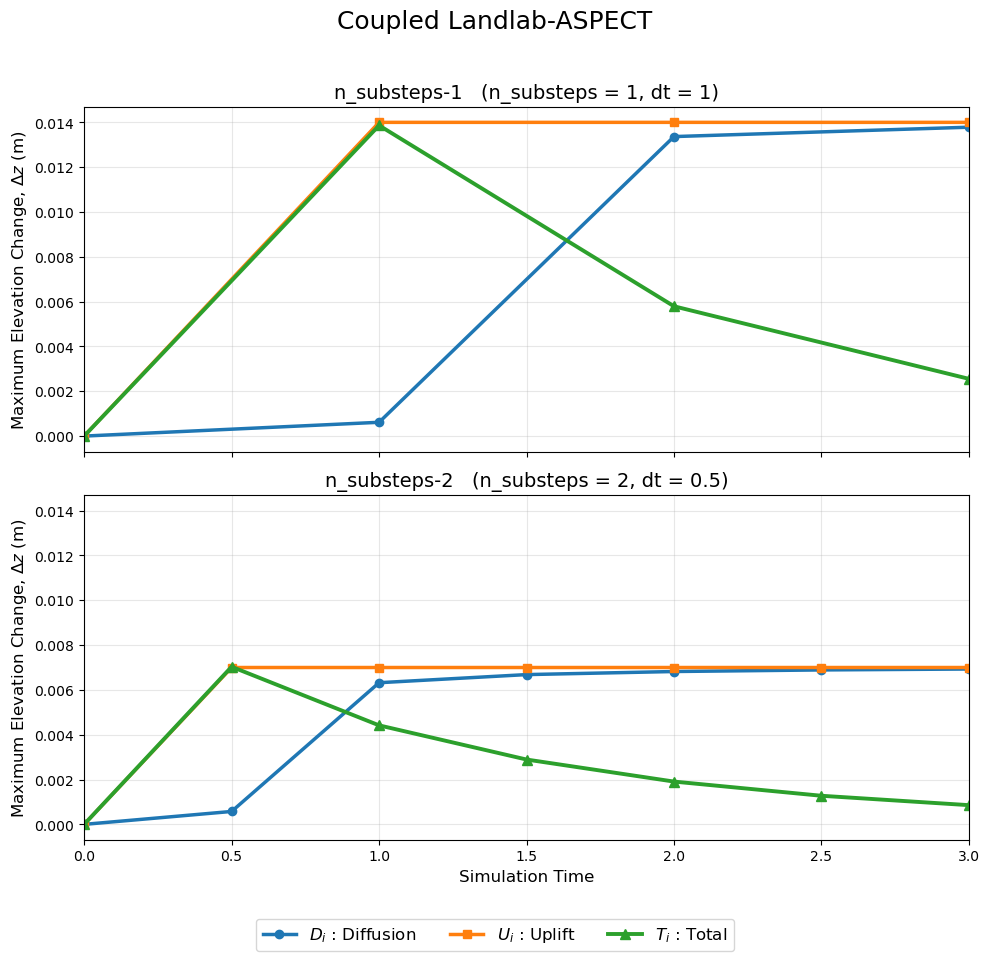

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SELECT CASES TO COMPARE
# ============================================================

case1 = "n_substeps-1"
case2 = "n_substeps-2"

# ============================================================
# BUILD FILE PATHS
# ============================================================

base_dir = Path("outputs")

file1 = (
    base_dir
    / case1
    / "outputs"
    / "tracer_analysis"
    / "elevation_tracer_rank_0.txt"
)

file2 = (
    base_dir
    / case2
    / "outputs"
    / "tracer_analysis"
    / "elevation_tracer_rank_0.txt"
)

print("\nReading files:")
print(file1)
print(file2)

# ============================================================
# COLUMN NAMES
# ============================================================

columns = [
    "aspect_step",
    "loop",
    "time",
    "dt",
    "n_substeps",
    "max_diffusion_change",
    "max_uplift_change",
    "max_total_change",
    "max_elevation",
]

# ============================================================
# READ DATA
# ============================================================

df1 = pd.read_csv(
    file1,
    sep=r"\s+",
    comment="#",
    header=None,
)

df2 = pd.read_csv(
    file2,
    sep=r"\s+",
    comment="#",
    header=None,
)

df1.columns = columns
df2.columns = columns

# ============================================================
# EXTRACT METADATA
# ============================================================

dt1 = float(df1["dt"].iloc[0])
dt2 = float(df2["dt"].iloc[0])

n1 = int(df1["n_substeps"].iloc[0])
n2 = int(df2["n_substeps"].iloc[0])

# ============================================================
# TIME ARRAYS
# Shift to end of timestep
# ============================================================

time1 = np.concatenate(
    ([0.0], df1["time"].values)
)

time2 = np.concatenate(
    ([0.0], df2["time"].values)
)

# ============================================================
# DATA ARRAYS
# ============================================================

D1 = np.concatenate(
    ([0.0], df1["max_diffusion_change"].values)
)

U1 = np.concatenate(
    ([0.0], df1["max_uplift_change"].values)
)

T1 = np.concatenate(
    ([0.0], df1["max_total_change"].values)
)

D2 = np.concatenate(
    ([0.0], df2["max_diffusion_change"].values)
)

U2 = np.concatenate(
    ([0.0], df2["max_uplift_change"].values)
)

T2 = np.concatenate(
    ([0.0], df2["max_total_change"].values)
)

# ============================================================
# COMMON Y LIMITS
# ============================================================

all_values = np.concatenate(
    [
        D1, U1, T1,
        D2, U2, T2,
    ]
)

ymin = np.min(all_values)
ymax = np.max(all_values)

padding = 0.05 * (ymax - ymin)

# ============================================================
# CREATE FIGURE
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 10),
    sharex=True,
    sharey=True,
)

# ============================================================
# TOP PANEL
# ============================================================

lineD, = ax1.plot(
    time1,
    D1,
    marker="o",
    linewidth=2.5,
    markersize=6,
    color="tab:blue",
    label=r"$D_i$ : Diffusion",
)

lineU, = ax1.plot(
    time1,
    U1,
    marker="s",
    linewidth=2.5,
    markersize=6,
    color="tab:orange",
    label=r"$U_i$ : Uplift",
)

lineT, = ax1.plot(
    time1,
    T1,
    marker="^",
    linewidth=2.8,
    markersize=7,
    color="tab:green",
    label=r"$T_i$ : Total",
)

ax1.set_title(
    f"{case1}   (n_substeps = {n1}, dt = {dt1:g})",
    fontsize=14,
)

ax1.set_ylabel(
    r"Maximum Elevation Change, $\Delta z$ (m)",
    fontsize=12,
)

ax1.grid(True, alpha=0.3)

# ============================================================
# BOTTOM PANEL
# ============================================================

ax2.plot(
    time2,
    D2,
    marker="o",
    linewidth=2.5,
    markersize=6,
    color="tab:blue",
)

ax2.plot(
    time2,
    U2,
    marker="s",
    linewidth=2.5,
    markersize=6,
    color="tab:orange",
)

ax2.plot(
    time2,
    T2,
    marker="^",
    linewidth=2.8,
    markersize=7,
    color="tab:green",
)

ax2.set_title(
    f"{case2}   (n_substeps = {n2}, dt = {dt2:g})",
    fontsize=14,
)

ax2.set_xlabel(
    "Simulation Time",
    fontsize=12,
)

ax2.set_ylabel(
    r"Maximum Elevation Change, $\Delta z$ (m)",
    fontsize=12,
)

ax2.grid(True, alpha=0.3)

# ============================================================
# COMMON AXIS LIMITS
# ============================================================

for ax in (ax1, ax2):

    ax.set_xlim(
        0,
        max(time1.max(), time2.max())
    )

    ax.set_ylim(
        ymin - padding,
        ymax + padding,
    )

# ============================================================
# OVERALL TITLE
# ============================================================

fig.suptitle(
    "Coupled Landlab-ASPECT",
    fontsize=18,
    y=0.97,
)

# ============================================================
# SHARED LEGEND
# ============================================================

fig.legend(
    handles=[lineD, lineU, lineT],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    fontsize=12,
    frameon=True,
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0.08, 1, 0.95]
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

figure_dir = Path("figures_tracer_plots")

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

outfile = (
    figure_dir
    / f"comparison_{case1}_vs_{case2}.png"
)

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight",
)

print(f"\nSaved figure:\n{outfile}")

plt.show()